In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
from sklearn import linear_model

In [18]:
df = pd.read_csv("dataset/linear_data.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


Text(0, 0.5, 'Price')

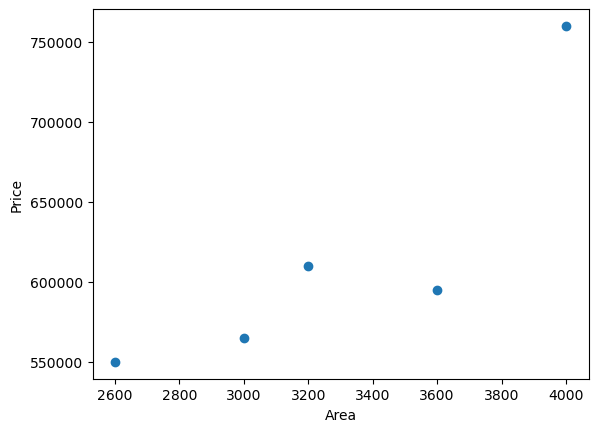

In [80]:
import matplotlib.pyplot as plt
plt.scatter(df.area, df.price)

plt.xlabel("Area")
plt.ylabel("Price")




In [43]:
# 1) create an object for linear regression then fit the data(training the liniear regre model using the variables)

reg = linear_model.LinearRegression()
reg.fit(df[['area']].values,df.price)


LinearRegression()

In [44]:
# 2) predict the prices
# getting the predicted values based on the formula y=mx+c,where
# both value are similar 
m = reg.coef_
c = reg.intercept_
y = m*([[3300]])+c
print(y)
reg.predict([[3300]])



[[628715.75342466]]


array([628715.75342466])

In [45]:
d = pd.read_csv("dataset/linear_prediction.csv")

In [48]:
p= reg.predict(d)
print(p)

[ 316404.10958904  384297.94520548  492928.08219178  661304.79452055
  740061.64383562  794376.71232877  926090.75342466  650441.78082192
  825607.87671233  492928.08219178 1402705.47945205 1348390.4109589
 1144708.90410959]


c:\Users\Shree\anaconda3\Lib\site-packages\sklearn\base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [40]:
# it creates a new column in df and tranport/export to csv(to_csv)
d['Price'] = p
d.to_csv("dataset/predicted.csv",index=False)

Text(0, 0.5, 'Price')

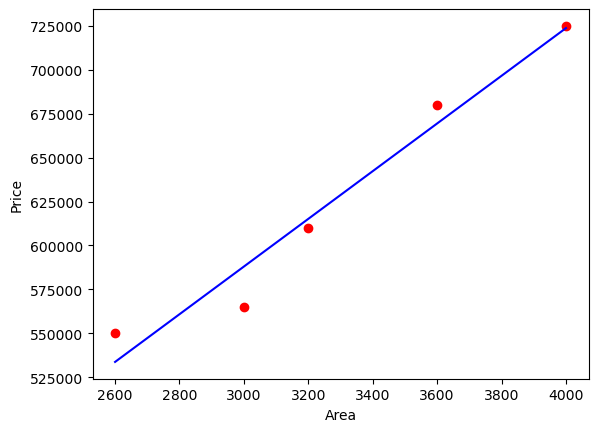

In [42]:
# plotting the linear line that we generated for each value
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.scatter(df.area, df.price,color="red")
plt.plot(df.area,reg.predict(df[['area']]),color="blue")
plt.xlabel("Area")
plt.ylabel("Price")

In [49]:
# Linear Regression --> Multiple variables (multivariate Regression)
# price = m1*val1+m2*val2+m3*val3+b (val's are features)(m1,m2,m3 are coefficients,b-intercept)

import pandas as pd
import numpy as np
from sklearn import linear_model


In [51]:
df = pd.read_csv("dataset/multi_linear.csv")
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


In [57]:
# Handled the NAN value --> assigned the median of that column 
# It is Data preprocessing stage - where need to process and analyse data
import math 
m_bedroom = math.floor(df.bedrooms.median())
df.bedrooms = df.bedrooms.fillna(m_bedroom)
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,3.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


In [58]:
# in reg.fir contains --> .fit(independent variables,target variables)
reg_multi = linear_model.LinearRegression()
reg_multi.fit(df[['area','bedrooms','age']],df.price)

LinearRegression()

In [73]:
m = reg_multi.coef_
b = reg_multi.intercept_

# reg_multi.predict(pd.DataFrame([[3000,3,15]],columns=['area','bedrooms','age']))
reg_multi.predict(pd.DataFrame([[2500,4,5]],columns=['area','bedrooms','age']))

array([588625.])

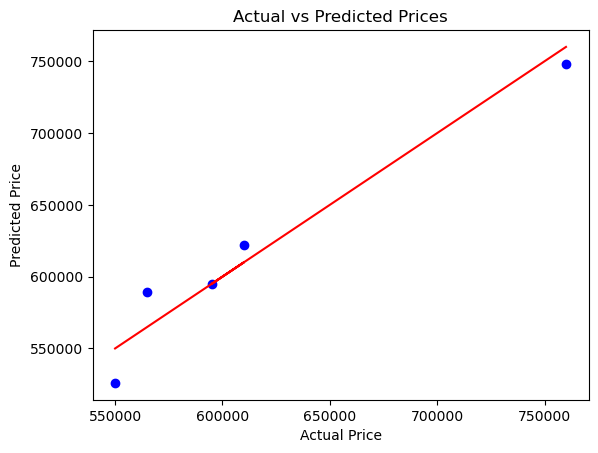

In [77]:
import matplotlib.pyplot as plt

# Predict for all rows
y_pred = reg_multi.predict(df[['area','bedrooms','age']])

plt.scatter(df.price, y_pred, color='blue')
plt.plot(df.price,df.price,color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()
